In [2]:
# Cell 0: Upgrade pip
import sys
print("Python:", sys.executable)

!python -m pip install --upgrade pip --quiet

print("✅ Pip upgraded successfully!")


Python: c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Scripts\python.exe
✅ Pip upgraded successfully!


In [3]:
# Cell 1: Install packages (after pip upgrade)
%pip install transformers torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

%pip install pillow opencv-python-headless python-docx matplotlib

print("✅ All packages installed!")

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement transformers (from versions: none)
ERROR: No matching distribution found for transformers


Note: you may need to restart the kernel to use updated packages.
✅ All packages installed!


In [4]:
import sys
print("Python version:", sys.version)
print("Python executable:", sys.executable)

# Clean install with extra flags
!python -m pip install --no-cache-dir --upgrade transformers --verbose

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Scripts\python.exe
Using pip 26.0.1 from c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\pip (python 3.11)
  Obtaining dependency information for transformers from https://files.pythonhosted.org/packages/a0/09/dd2f76acc40988d235ed020506722f867430c66b8bf2b7cbce2f822a982c/transformers-5.5.1-py3-none-any.whl.metadata
  Obtaining dependency information for huggingface-hub<2.0,>=1.5.0 from https://files.pythonhosted.org/packages/57/d4/e33bf0b362810a9b96c5923e38908950d58ecb512db42e3730320c7f4a3a/huggingface_hub-1.9.2-py3-none-any.whl.metadata
  Obtaining dependency information for pyyaml>=5.1 from https://files.pythonhosted.org/packages/da/e3/ea007450a105ae919a72393cb06f122f288ef60bba2dc64b26e2646fa315/pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for regex>=2025.10.22 f

In [5]:
import sys
print("Python:", sys.executable)

import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import cv2

print("\n✅ SUCCESS! All main libraries imported.")
print(f"GPU Available: {torch.cuda.is_available()}")

Python: c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Scripts\python.exe


c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✅ SUCCESS! All main libraries imported.
GPU Available: True


In [6]:
# Preporcessing Function
# Cell 4: Image Preprocessing for messy prescriptions
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Noise reduction
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Adaptive thresholding (best for varying lighting in prescriptions)
    thresh = cv2.adaptiveThreshold(blurred, 255, 
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    # Slight dilation to connect broken characters
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    
    # Convert to PIL format for TrOCR
    processed_pil = Image.fromarray(cv2.cvtColor(dilated, cv2.COLOR_GRAY2RGB))
    
    print(f"✅ Preprocessed: {image_path}")
    return processed_pil, img  # processed for model, original for display

In [ ]:
# Load TrOCR model
# Cell 5: Load TrOCR Model (Best for handwritten text)
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ TrOCR Model loaded successfully on {device}!")

In [7]:
# Recognition Function
# Cell 6: Main Recognition Function
def recognize_handwriting(image_path):
    # Preprocess
    processed_image, original_img = preprocess_image(image_path)
    
    # Display original vs processed
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    ax[1].imshow(processed_image)
    ax[1].set_title("Preprocessed for Model")
    ax[1].axis('off')
    plt.show()
    
    # Run TrOCR
    pixel_values = processor(images=processed_image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)
    
    generated_ids = model.generate(pixel_values, max_new_tokens=500)
    recognized_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    print("\n" + "="*60)
    print("✅ RECOGNIZED TEXT:")
    print("="*60)
    print(recognized_text)
    print("="*60)
    
    return recognized_text

In [8]:
# Save to Word Document
# Cell 7: Save output to Word file
from docx import Document
from docx.shared import Pt

def save_to_word(text, output_filename="recognized_prescription.docx"):
    doc = Document()
    
    # Title
    title = doc.add_heading('Handwriting Recognition Result - Doctor Prescription', level=0)
    title.alignment = 1  # Center align
    
    # Add text
    paragraph = doc.add_paragraph(text)
    run = paragraph.runs[0]
    run.font.size = Pt(11)
    
    doc.save(output_filename)
    print(f"✅ Successfully saved to: {output_filename}")
    
    # Auto download if in Colab, else just save
    try:
        from google.colab import files
        files.download(output_filename)
    except:
        print("File saved in current folder.")

✅ Preprocessed: C:\Users\Avilasha\Downloads\download.jpg


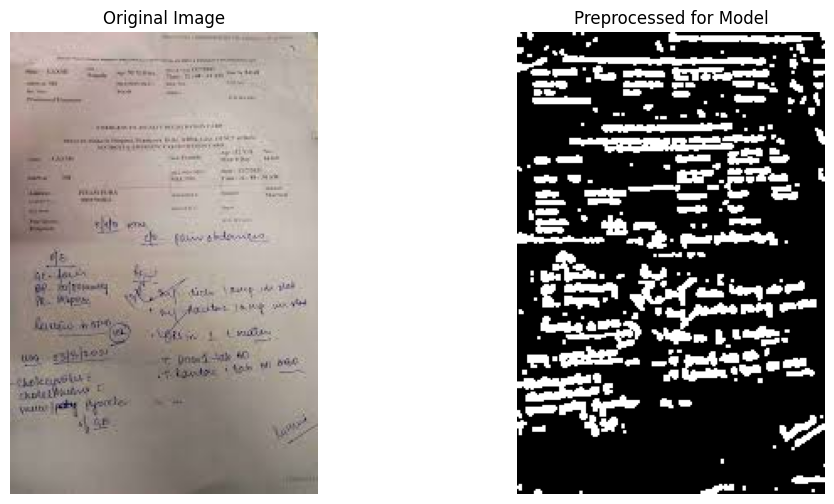

NameError: name 'processor' is not defined

In [9]:
# Cell 8: Run on your image
image_path = r"C:\Users\Avilasha\Downloads\download.jpg"   # ← CHANGE THIS PATH

recognized_text = recognize_handwriting(image_path)
save_to_word(recognized_text, "doctor_prescription_recognized.docx")